In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

#1.DATA COLLECTION

In [12]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-03-07,23.071566,23.288987,22.865468,23.189335,143315600
2016-03-08,22.881319,23.046651,22.738637,22.824699,126247600
2016-03-09,22.901709,23.005889,22.709199,22.944739,108806800
2016-03-10,22.913033,23.155367,22.682023,22.967389,134054400
2016-03-11,23.159891,23.164420,22.987766,23.155361,109632800
...,...,...,...,...,...
2026-02-26,272.950012,276.109985,270.799988,274.950012,32345100
2026-02-27,264.179993,272.809998,262.890015,272.809998,72366500


2.DATA VISSUALIZATION

Text(0, 0.5, 'Close price')

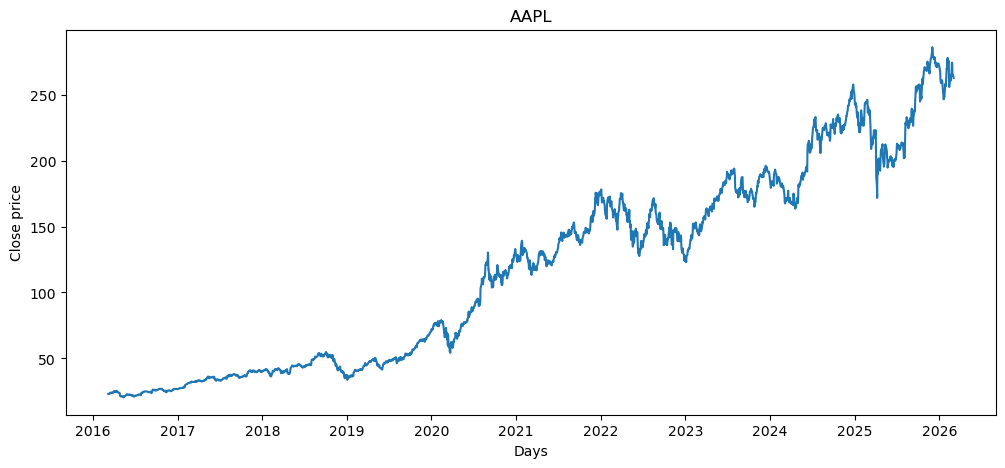

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close price')

3.FEATURE ENGINEERING

100DMA

In [14]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()


Price,Close,High,Low,Open,Volume,MA_100
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2016-03-07,23.071566,23.288987,22.865468,23.189335,143315600,NaN
2016-03-08,22.881319,23.046651,22.738637,22.824699,126247600,NaN
2016-03-09,22.901709,23.005889,22.709199,22.944739,108806800,NaN
2016-03-10,22.913033,23.155367,22.682023,22.967389,134054400,NaN
2016-03-11,23.159891,23.164420,22.987766,23.155361,109632800,NaN


Text(0, 0.5, 'Price')

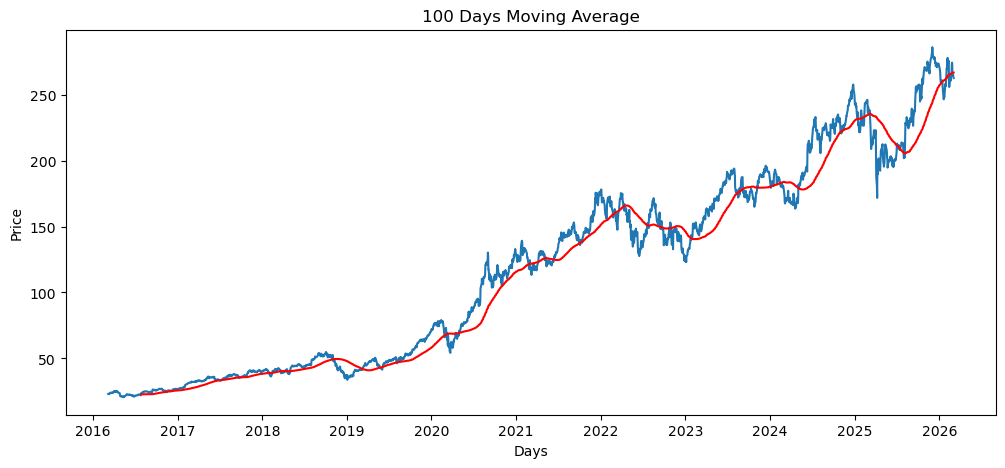

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

200DMA

In [18]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(203)

Price,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2016-03-07,23.071566,23.288987,22.865468,23.189335,143315600,NaN,NaN
2016-03-08,22.881319,23.046651,22.738637,22.824699,126247600,NaN,NaN
2016-03-09,22.901709,23.005889,22.709199,22.944739,108806800,NaN,NaN
2016-03-10,22.913033,23.155367,22.682023,22.967389,134054400,NaN,NaN
2016-03-11,23.159891,23.164420,22.987766,23.155361,109632800,NaN,NaN
...,...,...,...,...,...,...,...
2016-12-15,26.669867,26.879413,26.534008,26.568547,186098000,25.446885,NaN
2016-12-16,26.704407,26.826450,26.630720,26.819542,177404400,25.479348,24.116290


Text(0, 0.5, 'Price')

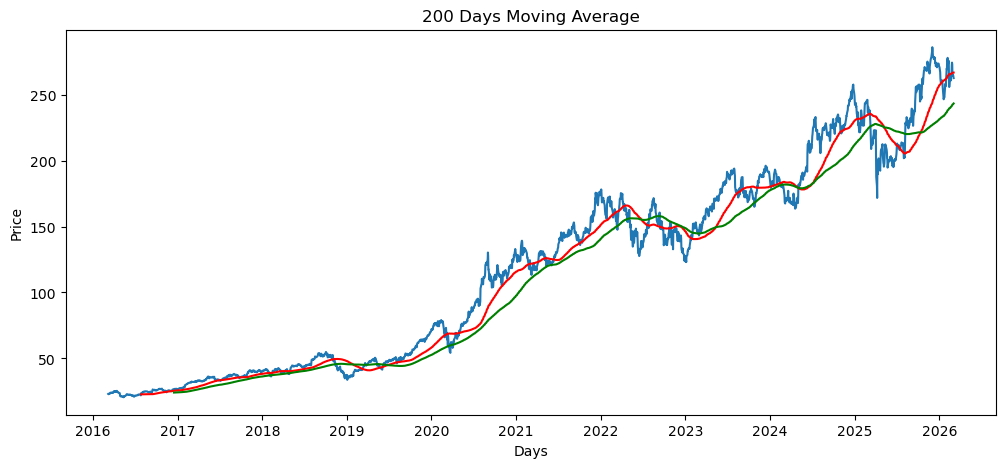

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title('200 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

CALCULATION CHANGE IN PERCENTAGE 

In [20]:
df['Percentage Chaged'] = df.Close.pct_change()
df[['Close', 'Percentage Chaged']]

Price,Close,Percentage Chaged
Ticker,AAPL,
Date,,
2016-03-07,23.071566,NaN
2016-03-08,22.881319,-0.008246
2016-03-09,22.901709,0.000891
2016-03-10,22.913033,0.000494
2016-03-11,23.159891,0.010774
...,...,...
2026-02-26,272.950012,-0.004668
2026-02-27,264.179993,-0.032130


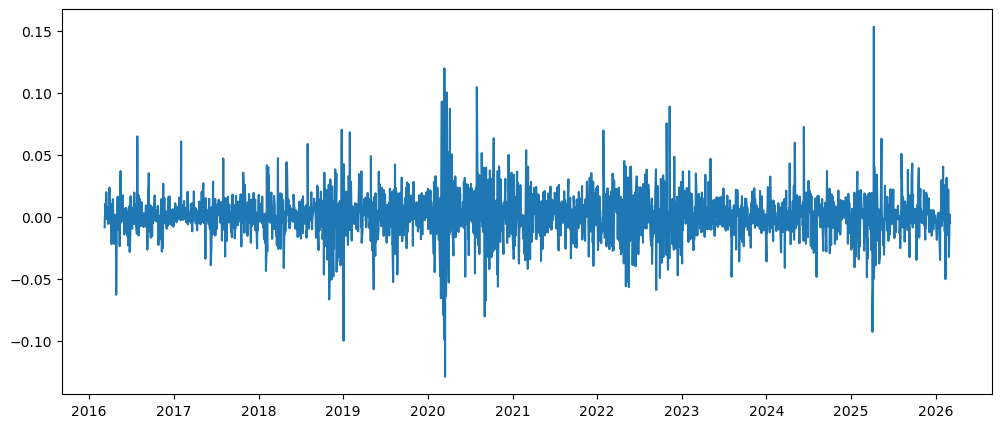

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage Chaged'])

4.DATA PREPROCESSING

In [22]:
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7): int(len(df))])

print(data_training)
print(data_testing)

Ticker            AAPL
Date                  
2016-03-07   23.071566
2016-03-08   22.881319
2016-03-09   22.901709
2016-03-10   22.913033
2016-03-11   23.159891
...                ...
2023-02-23  147.266525
2023-02-24  144.614975
2023-02-27  145.807678
2023-02-28  145.304947
2023-03-01  143.234940

[1759 rows x 1 columns]
Ticker            AAPL
Date                  
2023-03-02  143.826370
2023-03-03  148.873230
2023-03-06  151.633286
2023-03-07  149.435104
2023-03-08  150.686981
...                ...
2026-02-26  272.950012
2026-02-27  264.179993
2026-03-02  264.720001
2026-03-03  263.750000
2026-03-04  262.519989

[754 rows x 1 columns]


In [23]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [24]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.01578701],
       [0.01457924],
       [0.01470868],
       ...,
       [0.79497064],
       [0.79177908],
       [0.77863775]], shape=(1759, 1))

5. Sequence Creation

In [25]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])


x_train, y_train = np.array(x_train), np.array(y_train)


In [26]:
x_train

array([[[0.01578701],
        [0.01457924],
        [0.01470868],
        ...,
        [0.01012588],
        [0.00915667],
        [0.01824108]],

       [[0.01457924],
        [0.01470868],
        [0.01478057],
        ...,
        [0.00915667],
        [0.01824108],
        [0.02025177]],

       [[0.01470868],
        [0.01478057],
        [0.01634774],
        ...,
        [0.01824108],
        [0.02025177],
        [0.02006373]],

       ...,

       [[0.75790746],
        [0.78067569],
        [0.78254702],
        ...,
        [0.80116574],
        [0.80423205],
        [0.78739883]],

       [[0.78067569],
        [0.78254702],
        [0.77649635],
        ...,
        [0.80423205],
        [0.78739883],
        [0.79497064]],

       [[0.78254702],
        [0.77649635],
        [0.74318589],
        ...,
        [0.78739883],
        [0.79497064],
        [0.79177908]]], shape=(1659, 100, 1))

In [27]:
y_train

array([0.02025177, 0.02006373, 0.02272537, ..., 0.79497064, 0.79177908,
       0.77863775], shape=(1659,))

6. Model Building

In [28]:
import tensorflow as tf
print(tf.__version__)

# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input
model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

2.20.0


7. Model Training

In [29]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)


Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step - loss: 0.0190
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - loss: 6.6062e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - loss: 6.0772e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - loss: 6.8390e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - loss: 5.9038e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - loss: 5.5530e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - loss: 6.7038e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - loss: 5.4081e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - loss: 5.1707e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - loss: 4.8205e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - loss: 5.0391e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - loss: 5.5674e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - loss: 5.5670e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - loss: 4.9688e-04
Epo

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [31]:
# Save the trained model
model.save('stock_prediction_model.keras')

8. Preparing Test Data

In [32]:
data_training.tail(100)

Ticker,AAPL
Date,
2022-10-06,142.897629
2022-10-07,137.650604
2022-10-10,137.974869
2022-10-11,136.559937
2022-10-12,135.931091
...,...
2023-02-23,147.266525
2023-02-24,144.614975
2023-02-27,145.807678


In [33]:
data_testing

Ticker,AAPL
Date,
2023-03-02,143.826370
2023-03-03,148.873230
2023-03-06,151.633286
2023-03-07,149.435104
2023-03-08,150.686981
...,...
2026-02-26,272.950012
2026-02-27,264.179993
2026-03-02,264.720001


In [34]:
past_100_days = data_training.tail(100)

In [35]:
past_100_days

Ticker,AAPL
Date,
2022-10-06,142.897629
2022-10-07,137.650604
2022-10-10,137.974869
2022-10-11,136.559937
2022-10-12,135.931091
...,...
2023-02-23,147.266525
2023-02-24,144.614975
2023-02-27,145.807678


In [36]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

Ticker,AAPL
0,142.897629
1,137.650604
2,137.974869
3,136.559937
4,135.931091
...,...
849,272.950012
850,264.179993
851,264.720001
852,263.750000


In [37]:
input_data = scaler.fit_transform(final_df)
# input_data

In [38]:
input_data.shape

(854, 1)

In [39]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [40]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [41]:
x_test[0].shape

(100, 1)

In [42]:
x_test

array([[[0.12187721],
        [0.0896623 ],
        [0.09165317],
        ...,
        [0.1397439 ],
        [0.1366573 ],
        [0.12394818]],

       [[0.0896623 ],
        [0.09165317],
        [0.08296598],
        ...,
        [0.1366573 ],
        [0.12394818],
        [0.12757936]],

       [[0.09165317],
        [0.08296598],
        [0.07910508],
        ...,
        [0.12394818],
        [0.12757936],
        [0.15856532]],

       ...,

       [[0.81752464],
        [0.81623798],
        [0.82592019],
        ...,
        [0.92821245],
        [0.9203537 ],
        [0.86650883]],

       [[0.81623798],
        [0.82592019],
        [0.80128551],
        ...,
        [0.9203537 ],
        [0.86650883],
        [0.86982429]],

       [[0.82592019],
        [0.80128551],
        [0.74754331],
        ...,
        [0.86650883],
        [0.86982429],
        [0.86386882]]], shape=(754, 100, 1))

9. Making Predictions

In [43]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step


In [44]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

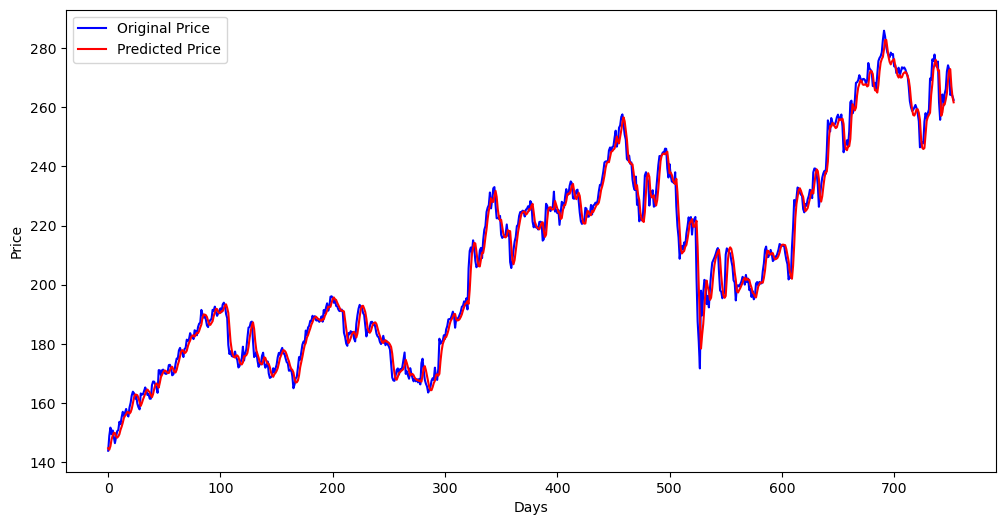

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(140.0, 220.0)

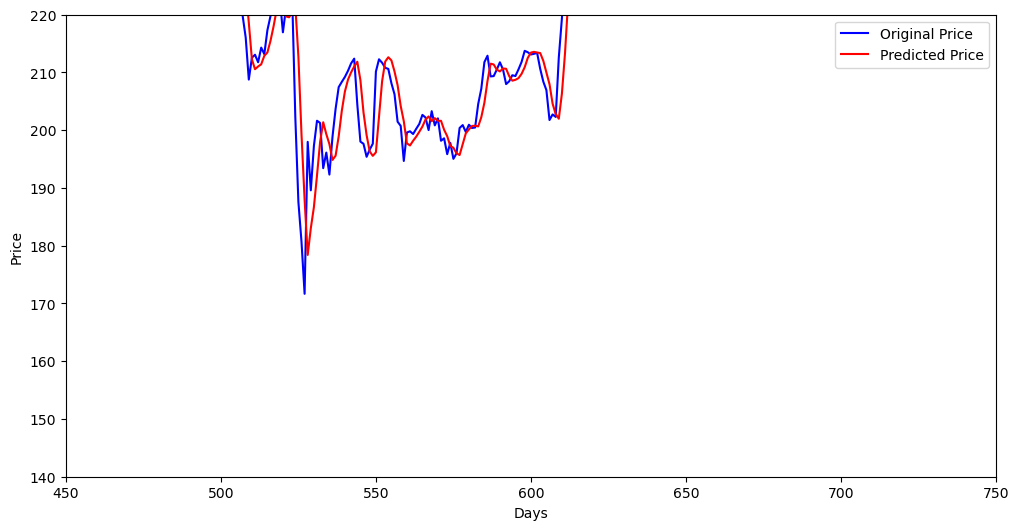

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450, 750)
plt.ylim(140, 220)

10. Model Evaluation

In [47]:
from sklearn.metrics import mean_squared_error, r2_score

In [48]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 16.777337854887435


In [49]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 4.09601487483718


In [50]:
# R-Squared
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}")

R-Squared: 0.985233153255112
